In [84]:
import numpy as np
import matplotlib.pyplot as plt

In [85]:
# Dimensions
no_of_sources=5
no_of_slots=4
P_total = 2.5
max_iters = 1000
snr=50  #from o to snr

In [86]:
eta = 0.01           # learning rate for B
eta_lambda = 0.1     # learning rate for lambda
tol = 1e-6

In [ ]:
B = np.random.randn(no_of_slots, no_of_sources)  # Initial B value
# print("B=",B,"\n")
lambda_reg = 1.0      # Initial value of lambda

def norm(arr):
    return np.sum(arr * arr, axis=0)

for iter in range(max_iters):
    np.random.seed(3)
    H = np.random.randn(no_of_slots, no_of_sources)
    x = np.random.uniform(-1, 1, size=(no_of_sources, 1))  # Uniform distribution between -1 and 1
    z = np.random.randn(no_of_slots, 1)
    
    
    BH = B * H
    y = BH @ x +z  - np.sum(x)
    grad = 2 * (y @ x.T) * H + 2 * lambda_reg * B

    # Gradient step
    B_new = B - eta * grad
    colwise_norms = norm(B_new)

    # print("norm=", colwise_norms, "\n")
    # print((colwise_norms > P_total), "\n")

    # Make a copy to apply corrections 
    B_new1 = B_new.copy()

    # Check if any column has a squared norm greater than P_total
    if any(colwise_norms > P_total):      
        for i in range(B_new.shape[1]):  # Iterate over each column
            if colwise_norms[i] > P_total:
                scaling_factor = np.sqrt(P_total / colwise_norms[i])
                B_new1[:, i] *= scaling_factor
                # print(norm(B_new1[:, i]) > P_total)  # Should print False

        # Dual update: Based on the total column norms exceeding P_total
        total_col_sum = np.sum(colwise_norms)
        lambda_reg += eta_lambda * (total_col_sum - P_total)
        lambda_reg = max(0, lambda_reg)

    # Convergence check
    if np.linalg.norm(B_new1 - B, ord='fro') < tol:
        print(f"Converged at iteration {iter}")
        break

    # Update B
    B = B_new1


In [88]:
# Function to compute MMSE for one round
def compute_mmse(B, H, x, snr_db):
    n = B.shape[0]
    BH = B * H
    signal = BH @ x
    P_signal = np.sum(x**2) / n
    snr_linear = 10 ** (snr_db / 10)
    P_noise = P_signal / snr_linear
    z = np.random.normal(0, np.sqrt(P_noise), size=(n, 1))
    y = signal + z
    target = np.sum(x)
    mmse = np.sum((y - target) ** 2) / n
    return mmse

In [89]:
snrs = np.arange(0, snr+1)
mmse_vals = []
for snr_db in snrs:
    mmse_list = [compute_mmse(B, H, x, snr_db) for _ in range(max_iters)]
    mmse_vals.append(np.mean(mmse_list))
    
print("mse",mmse_vals)

mse [3.817553824767546, 3.804488610637425, 3.677326118985628, 3.6584944090127616, 3.595399150834878, 3.5972543560828725, 3.5764214299070263, 3.5113624601986633, 3.4958395025866746, 3.5095700832865453, 3.5078359267778003, 3.501360501940169, 3.480054612463341, 3.4699162346825916, 3.467111867165032, 3.4691451887882487, 3.4714943379252956, 3.4576774853142678, 3.458190492123349, 3.467327682482466, 3.4581080347371542, 3.4527047669348305, 3.451432858816693, 3.4552045228506536, 3.4555782441481124, 3.455586241571037, 3.454650461558524, 3.454704380137461, 3.456373295196136, 3.455517802345185, 3.4553880989412438, 3.4514458746955157, 3.4543011750308104, 3.454301624867354, 3.453767067767276, 3.454687789228988, 3.4549736941013474, 3.453759329576694, 3.4542957268351, 3.4540929981299424, 3.4534669305120698, 3.454143732605282, 3.453313465496498, 3.4538759099633576, 3.4536614218076958, 3.453340011617241, 3.4541547682533174, 3.4539350752990603, 3.4536934872327736, 3.453862903655126, 3.453959958040521]


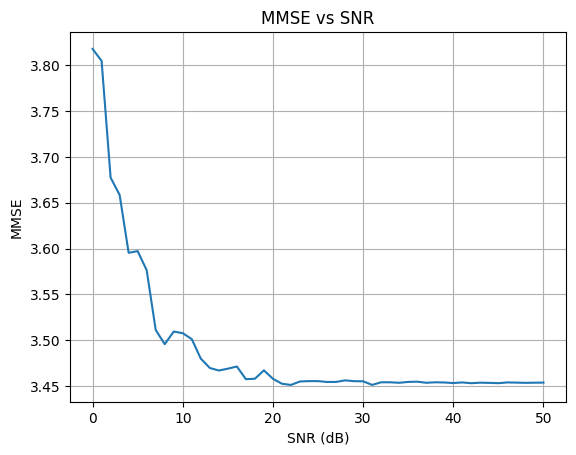

In [ ]:
# Plot

plt.plot(snrs, mmse_vals)
plt.xlabel('SNR (dB)')
plt.ylabel('MMSE')
plt.title('MMSE vs SNR')
plt.grid(True)
plt.show()